# ConvNeXt-Tiny Artifact Visualizer

This notebook reads the locally saved ConvNeXt-Tiny evaluation artifacts and builds quick plots for presentation and analysis. It does not rerun training.

If no evaluation artifacts are found yet, rerun the final evaluation and save cells in the ConvNeXt notebook first.

In [3]:
from pathlib import Path
import sys


def find_repo_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() or (candidate / "artifacts").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.artifact_visualizer import display_artifact_dashboard


## ConvNeXt-Tiny Artifact Dashboard

Using saved artifacts from `artifacts\ConvNeXt-Tiny\V3\evaluation_artifacts\convnext_tiny_v3`

### Summary Metrics

,Metric,Score (%)
0,Validation Accuracy,87.71
1,Macro Precision,79.88
2,Macro Recall,75.57
3,Macro F1,77.33
4,Weighted F1,87.53


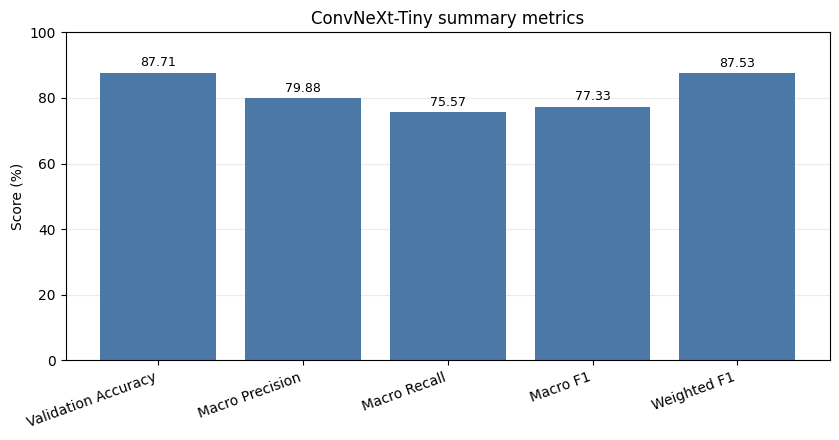

### Training Curves

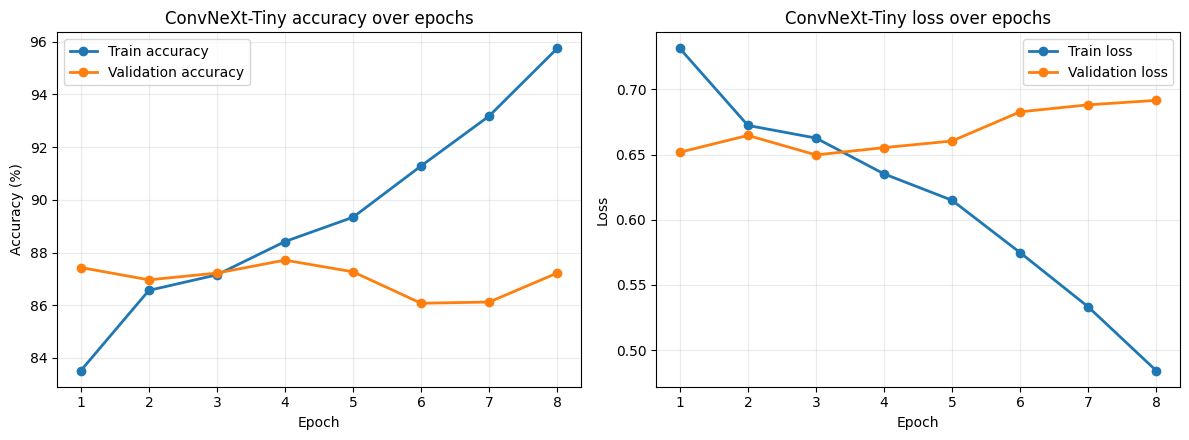

### Per-Class Metrics

,precision,recall,f1-score,support
Cassava Bacterial Blight (CBB),0.679,0.576,0.623,217.0
Cassava Brown Streak Disease (CBSD),0.861,0.719,0.784,438.0
Cassava Green Mottle (CGM),0.834,0.717,0.771,477.0
Cassava Mosaic Disease (CMD),0.944,0.974,0.959,2632.0
Healthy,0.676,0.793,0.730,516.0


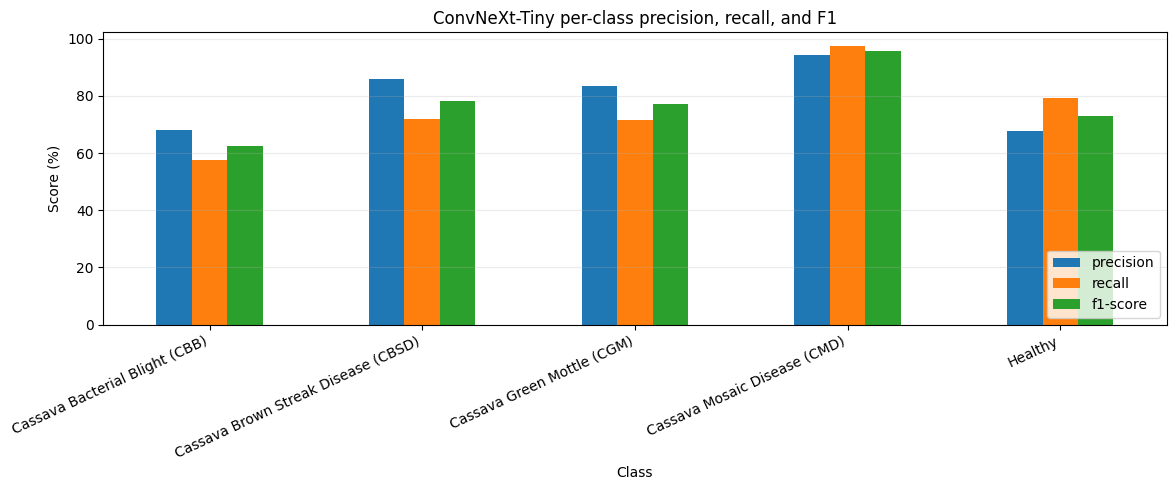

### Confusion Matrix

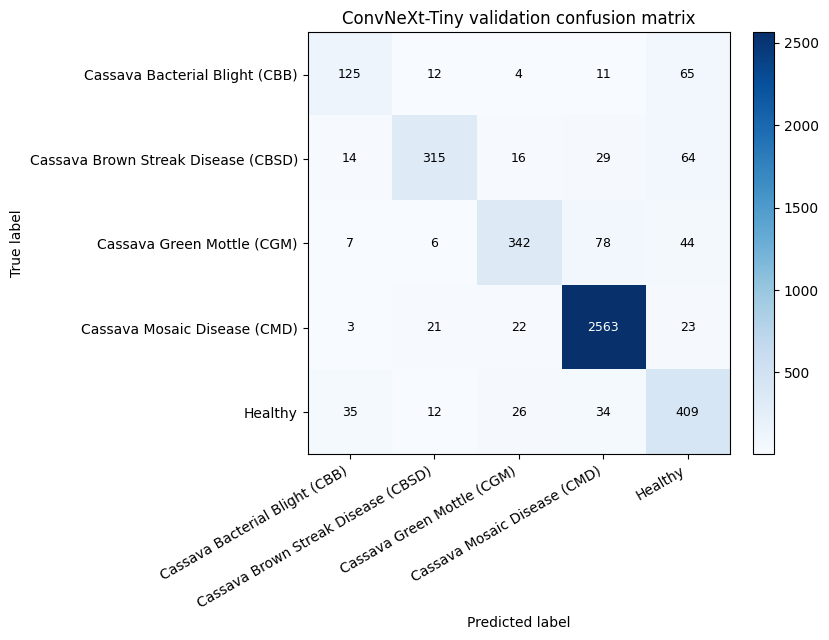

### Highest-Confidence Validation Mistakes

,image_id,true_name,pred_name,label,pred_label,confidence
1202,2338166652.jpg,Cassava Mosaic Disease (CMD),Cassava Brown Streak Disease (CBSD),3,1,0.932022
1283,939153733.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.931772
2261,1365612235.jpg,Healthy,Cassava Mosaic Disease (CMD),4,3,0.929417
3462,1054935979.jpg,Cassava Brown Streak Disease (CBSD),Cassava Mosaic Disease (CMD),1,3,0.929242
3611,2191616657.jpg,Healthy,Cassava Mosaic Disease (CMD),4,3,0.928969
2268,3722626623.jpg,Cassava Brown Streak Disease (CBSD),Cassava Mosaic Disease (CMD),1,3,0.927751
2836,1654084150.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.924952
2018,3308428199.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.923864
1352,1184986094.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.923747
354,658285764.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.923347


In [4]:
MODEL_FAMILY = "ConvNeXt-Tiny"
PREFERRED_SUBDIR = "V3"
ARTIFACT_DIR_OVERRIDE = None
# Example override:
# ARTIFACT_DIR_OVERRIDE = repo_root / "artifacts" / "ConvNeXt-Tiny" / "V3" / "evaluation_artifacts" / "convnext_tiny_v3"

try:
    artifact_bundle = display_artifact_dashboard(
        model_family=MODEL_FAMILY,
        preferred_subdir=PREFERRED_SUBDIR,
        override=ARTIFACT_DIR_OVERRIDE,
    )
except FileNotFoundError as exc:
    print(exc)
